In [ ]:
#İKİLİ SINIFLANDIRMA PROBLEMİ#

import numpy as np 
import keras 
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import matplotlib.pyplot as plt
%matplotlib inline

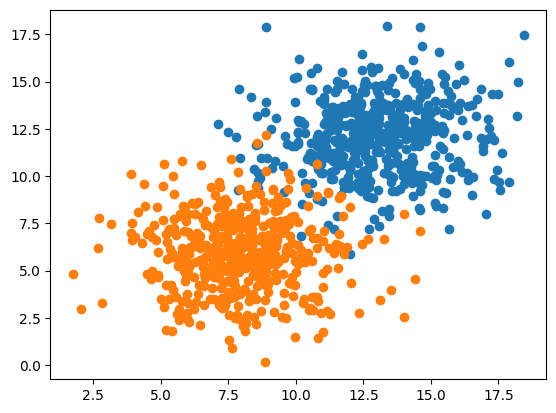

In [34]:
#kodu kaç defa çalıştırırsak çalıştıralım kodda hep aynı değerler üretilecek 

n_pts = 500
Xa = np.array([np.random.normal(13, 2, n_pts),
               np.random.normal(12, 2, n_pts)]).T  #A sınıfını üretiyoruz
Xb = np.array([np.random.normal(8, 2, n_pts),
               np.random.normal(6, 2, n_pts)]).T   #B sınıfını üretiyoruz
 
X = np.vstack((Xa, Xb)) #üretilen sınıfları birleştirir

y = np.append(np.zeros(n_pts), np.ones(n_pts)).reshape(-1, 1) # Boyut (1000, 1) olacak şekilde ayarlandı
 
plt.scatter(X[:n_pts,0], X[:n_pts,1])  #noktaları çiziyoruz 
plt.scatter(X[n_pts:,0], X[n_pts:,1])  

In [35]:
model = Sequential()
model.add(Dense(units = 1, input_shape=(2,), activation = 'sigmoid'))
adam = Adam(learning_rate = 0.1)
model.compile(adam, loss='binary_crossentropy', metrics=['accuracy'])
h = model.fit(x=X, y=y, verbose=1, batch_size=50, epochs = 500, shuffle='true') #1000 noktaya 500 kere bak her seferinde hatanı azalt

Epoch 1/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4980 - loss: 1.2254   
Epoch 2/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6310 - loss: 0.6033 
Epoch 3/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7550 - loss: 0.4867 
Epoch 4/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8750 - loss: 0.4004 
Epoch 5/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9060 - loss: 0.3431  
Epoch 6/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9420 - loss: 0.2981 
Epoch 7/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9450 - loss: 0.2718  
Epoch 8/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9530 - loss: 0.2426 
Epoch 9/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9600 - loss: 0.2216 
Epoch 10/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9640 - loss: 0.2044  
Epoch 11/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9660 - loss: 0.1899 
Epoch 12/500
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

In [1]:
plt.plot(h.history['accuracy']) #accuracy = doğruluk (kesinlik) 
plt.title('accuracy')
plt.xlabel('epoch') #x max değeri eğitim iterasyonumuz kadar
plt.legend(['accuracy']) 

NameError: name 'plt' is not defined

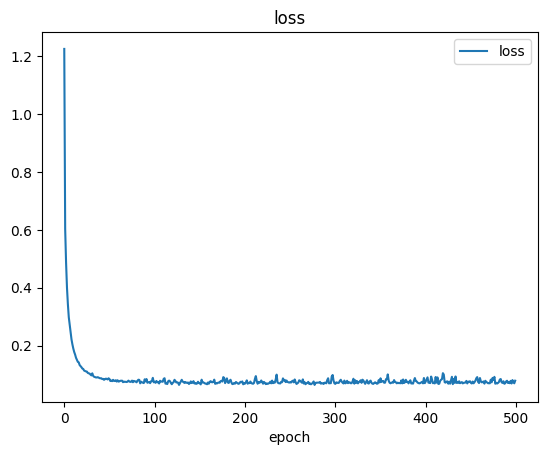

In [37]:
plt.plot(h.history['loss'])
plt.title('loss')
plt.xlabel('epoch')
plt.legend(['loss'])

In [57]:
def plot_decision_boundary(X,y,model):  #düzlemi kare kare böler kareye sorar ve cevaba göre o kareye renk atar
    x_span = np.linspace(min(X[:,0]) -1,max(X[:,0])+1,3)
    y_span = np.linspace(min(X[:,1]) -1,max(X[:,1])+1,3)
    xx, yy = np.meshgrid(x_span, y_span)
    xx_, yy_ = xx.ravel(), yy.ravel()
    grid = np.c_[xx_, yy_]
    pred_func = model.predict(grid)
    z = pred_func.reshape(xx.shape)
    plt.contourf(xx,yy,z)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


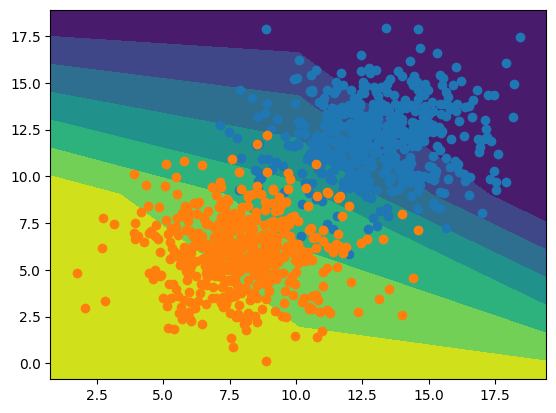

In [59]:
plot_decision_boundary(X,y,model)
plt.scatter(X[:n_pts,0], X[:n_pts,1])
plt.scatter(X[n_pts:,0], X[n_pts:,1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
prediction is: [[0.9999718]]


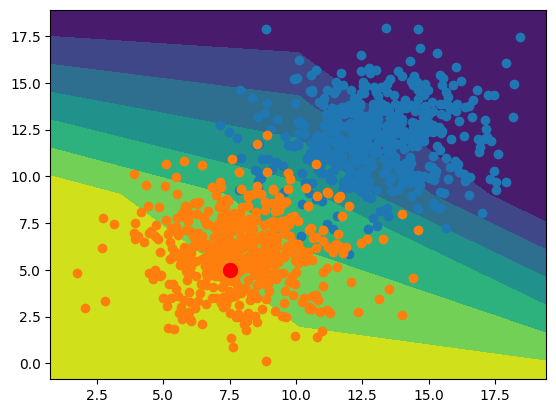

In [61]:
plot_decision_boundary(X,y,model)
plt.scatter(X[:n_pts,0], X[:n_pts,1])
plt.scatter(X[n_pts:,0], X[n_pts:,1])
x = 7.5
y = 5
point = np.array([[x,y]])
prediction = model.predict(point)
plt.plot([x],[y],marker="o",markersize=10,color="red")
print("prediction is:",prediction)